In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler # 데이터를 랜덤샘플링하기 위함
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING) # 수치가 떨어지면 경고로그가 뜨는데 그거를 막아줌

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주현 데이터, 순위 x)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위 O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터를 불러오기

In [2]:
train_df = pd.read_csv('data/bike_sharing_train.csv')
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [3]:
test_df = pd.read_csv('data/bike_sharing_test.csv')
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


- 결과 데이터로 사용 가능한 컬럼 : casual(비회원 대여 수), registered(회원 대여 수), count(총 대여 수)
- 본 프로젝트에서는 count를 예측할 것이다.
- casual과 registered는 제거한다.

In [4]:
train_df.drop(['casual','registered'], axis=1, inplace=True)
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129


### count 데이터 분석

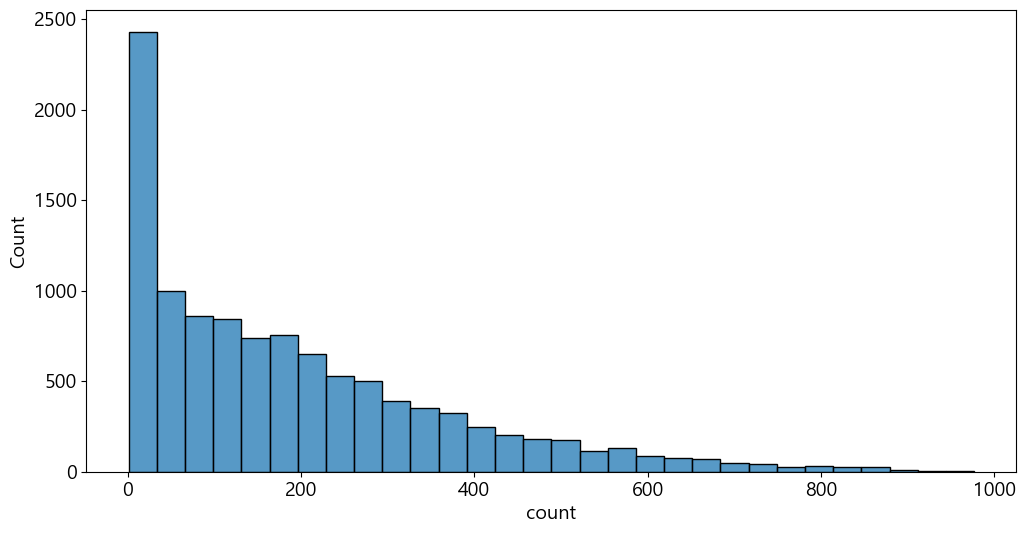

In [5]:
sns.histplot(data=train_df,x='count', bins=30)
plt.show()

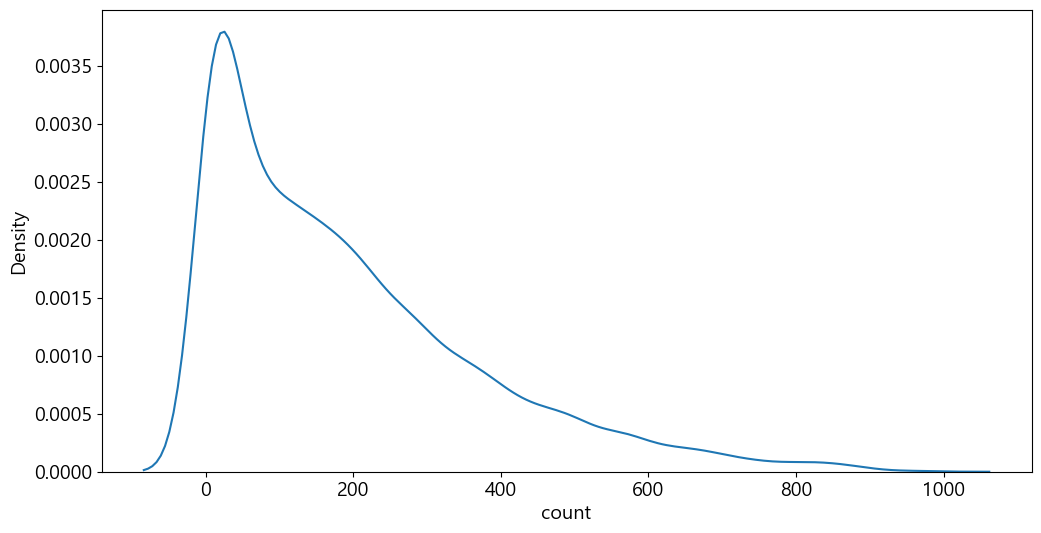

In [6]:
sns.kdeplot(data=train_df, x='count')
plt.show()

In [7]:
# 결과 데이터가 한쪽으로 치우쳐져 있기 때문에 로그값을 구해서 담아준다.
train_df['log_count'] = np.log1p(train_df['count'])
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147
...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534


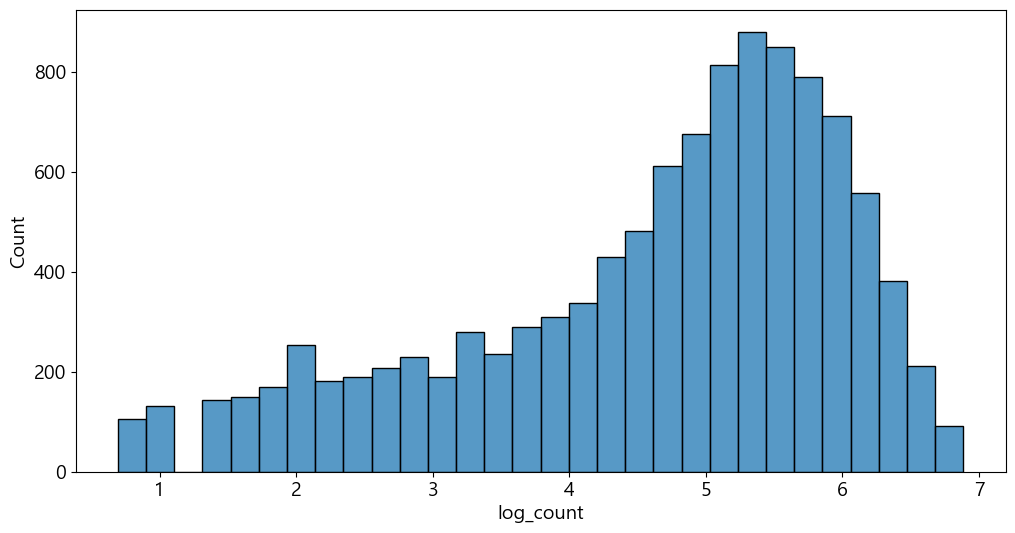

In [8]:
sns.histplot(data=train_df, x='log_count', bins=30)
plt.show()

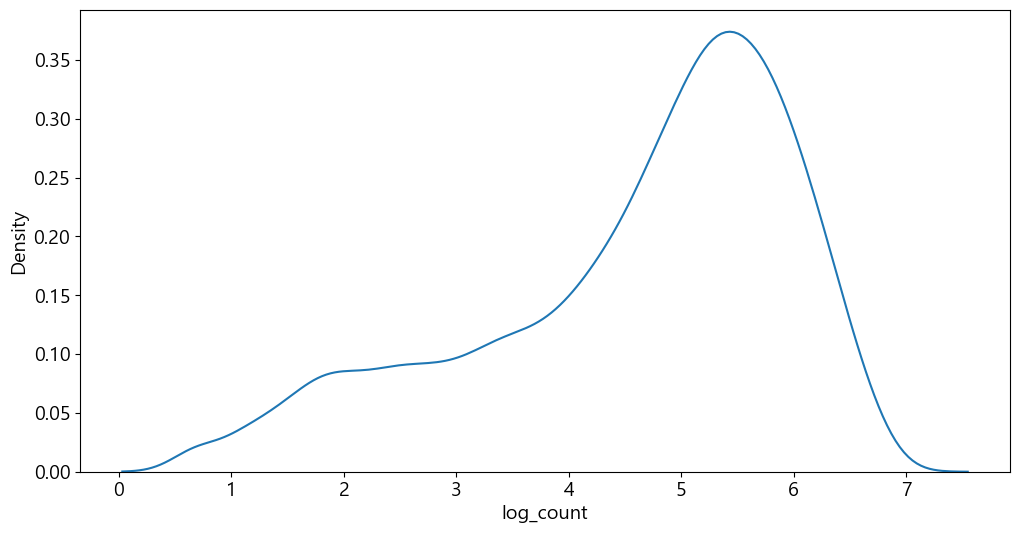

In [9]:
sns.kdeplot(data=train_df, x='log_count')
plt.show()

In [10]:
# 로그값을 원래대로 복원하는 방법 
# 로그값으로 예측 이후 원래대로 복원 할 예정
# a1 = np.expm1(train_df['log_count'])
# pd.DataFrame([a1,train_df['count']])

### 시계열 데이터 분석

In [11]:
# 시계열 데이터를 분해해서 사용할 수 있음
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
# 시계열 데이터 분해
# 1주일 간의 패턴을 보기 위해 24 * 7 = 168을 설정한다
decomposition = seasonal_decompose(train_df['log_count'], period=168)

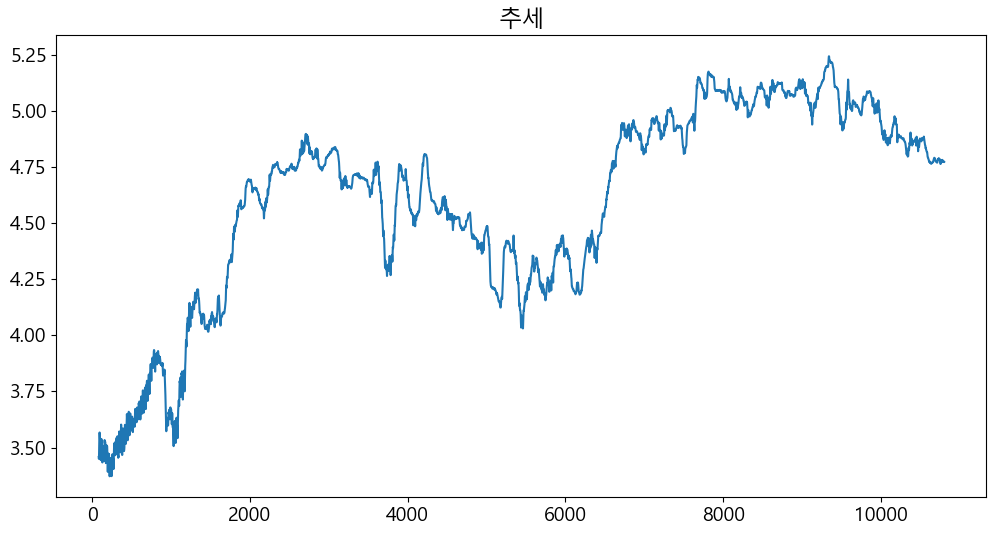

In [13]:
decomposition.trend.plot()
plt.title('추세')
plt.show()

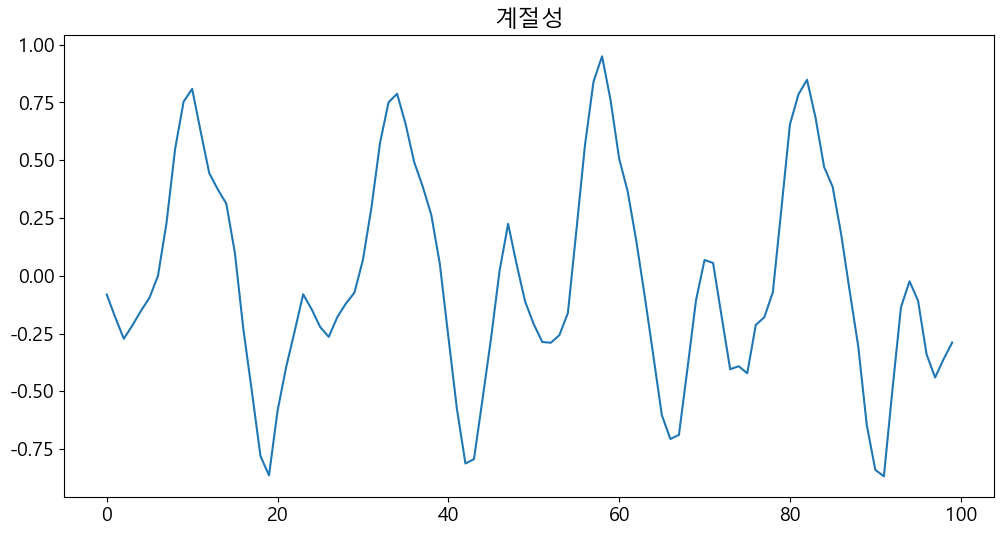

In [14]:
# 계절성
decomposition.seasonal[:100].plot()
plt.title('계절성')
plt.show()

- 24까지가 일주일 단위이다
- 계절성 그래프가 패턴이 비슷하게 움직여서 딥러닝을 활용 시 결과가 엄청나게 좋게 나오는 편이다

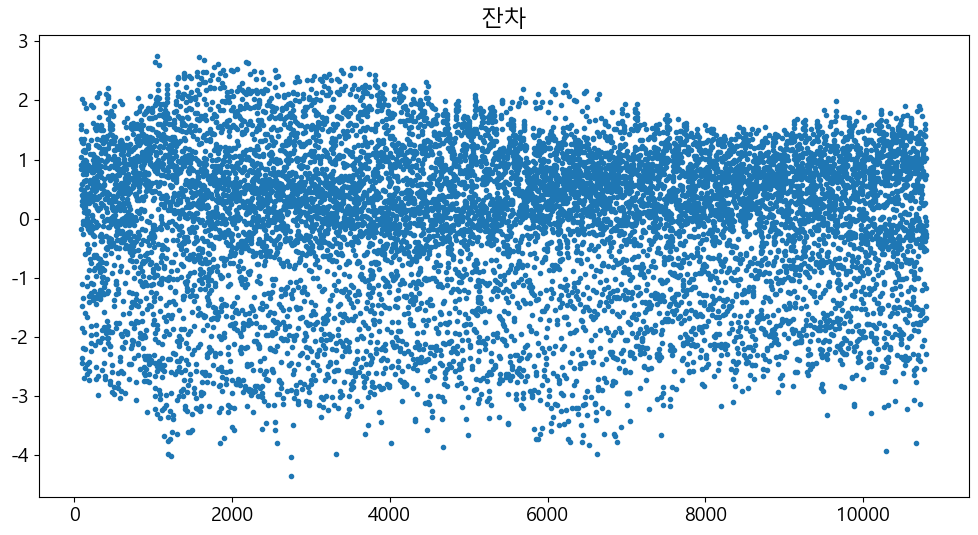

In [15]:
decomposition.resid.plot(style='.')
plt.title('잔차')
plt.show()

### datetime
- 일시, 시간, 단위의 날짜와 타임 스탬프
- 우리는 딥러닝이 아닌 전통적인 머신러닝을 사용할 것이다.
- 이에 각 행별로 결과 데이터를 예측하는 회귀 분석을 수행할 것이다.
- 따라서 datetime을 년,월,일,시로 분해하여 각각을 범주형 데이터로 사용할 것이다.

In [16]:
# datetime 컬럼을 날짜 타입으로 변경한다
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

# 년, 월, 일, 시 컬럼 생성
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour

train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083,2012,12,19,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938,2012,12,19,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899,2012,12,19,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534,2012,12,19,22


In [17]:
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour

test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22


### season
- 계절
- 1 = 봄, 2 = 여름, 3 = 가을, 4 = 겨울

In [18]:
# 도수 분포 확인
a1 = train_df['season'].value_counts()
a1.sort_index(inplace=True)
a1.index = ['봄','여름','가을','겨울']
a1

봄     2686
여름    2733
가을    2733
겨울    2734
Name: count, dtype: int64

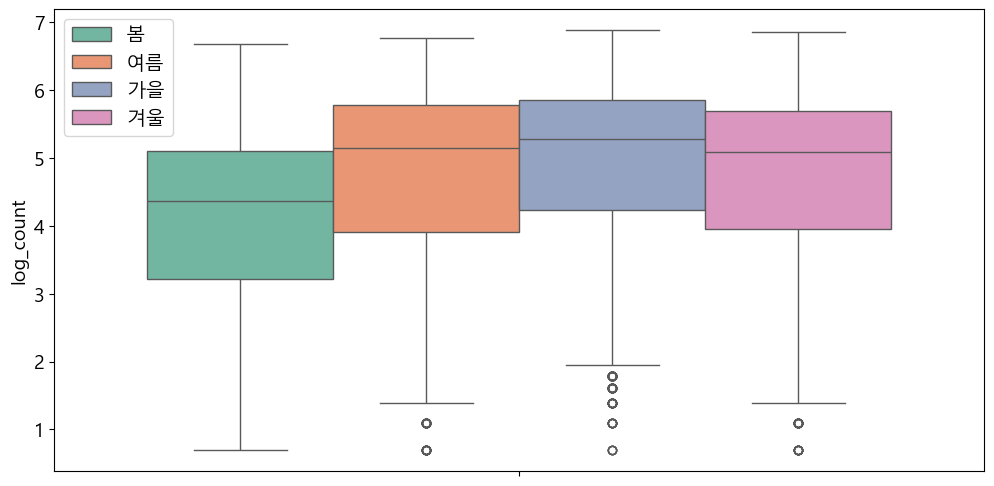

In [19]:
# season을 활용하여 boxplot을 그려본다
sns.boxplot(data=train_df,y='log_count', hue='season', palette='Set2')
plt.legend(labels=['봄','여름','가을','겨울'])
plt.show()

- 계절적인 추세를 보이고 있음

,season,log_count
2,3,4.885394
1,2,4.736112
3,4,4.684555
0,1,4.050051


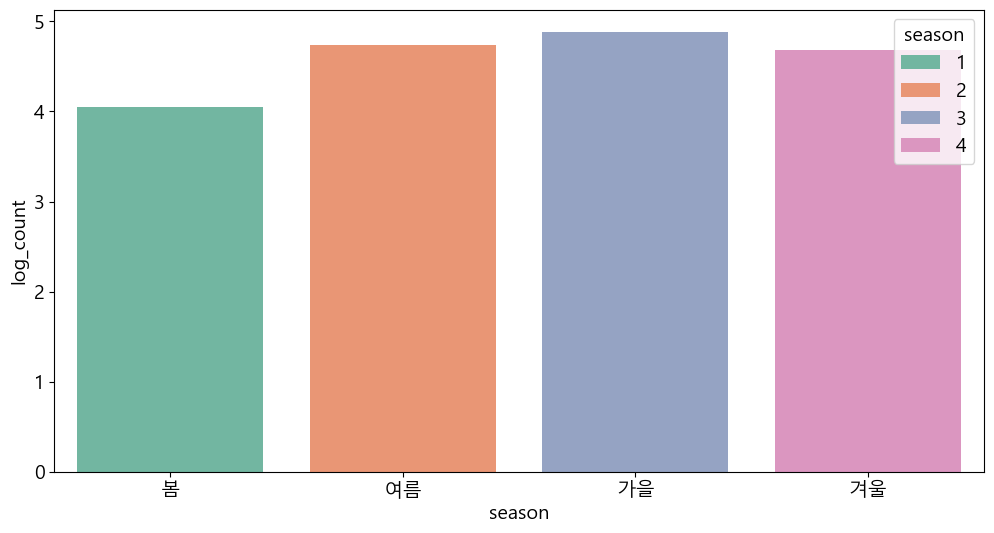

In [20]:
# season별 log_count의 평균 시각화
a1 = train_df.groupby('season', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='season', y='log_count', palette='Set2', hue='season')
plt.xticks([0,1,2,3],['봄','여름','가을','겨울'])
plt.show()

- 봄이 가장 낮다
- 봄 → 여름 → 가을 : 대여 수 증가
- 가을 → 겨울 → 봄 : 대여 수 감소

### holiday 
- 공휴일 여부
- 1 = 공휴일, 0 = 평일

In [21]:
# 도수 분포 확인
train_df['holiday'].value_counts()

holiday
0    10575
1      311
Name: count, dtype: int64

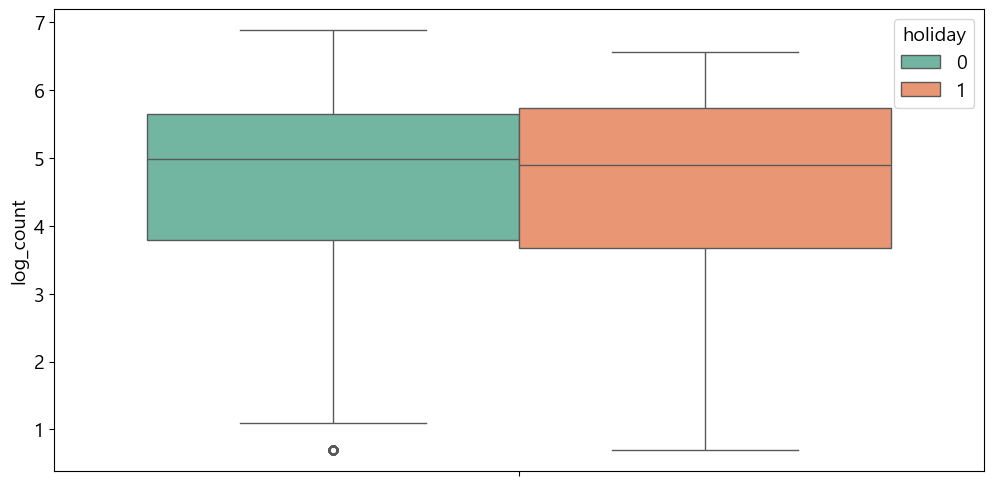

In [22]:
# holiday를 활용하여 boxplot 그리기
sns.boxplot(data=train_df, y='log_count', hue='holiday', palette='Set2')
plt.show()

,holiday,log_count
0,0,4.591663
1,1,4.581175


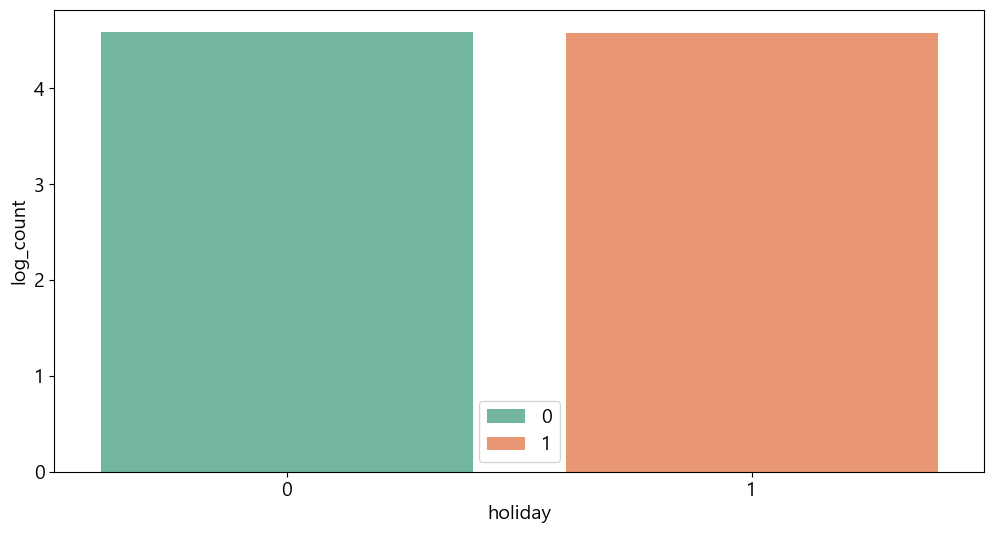

In [23]:
# holiday 별 log_count 평균 시각화
a1 = train_df.groupby('holiday', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='holiday', y='log_count', palette='Set2', hue='holiday')
plt.legend()
plt.show()

- 공휴일인 날과 공휴일이 아닌 날의 자전거 대여 횟수는 큰 차이가 없다

### workingday
- 근무일 여부
- 1 = 근무일 0 = 휴일

In [24]:
# 도수 분포 확인
train_df['workingday'].value_counts()

workingday
1    7412
0    3474
Name: count, dtype: int64

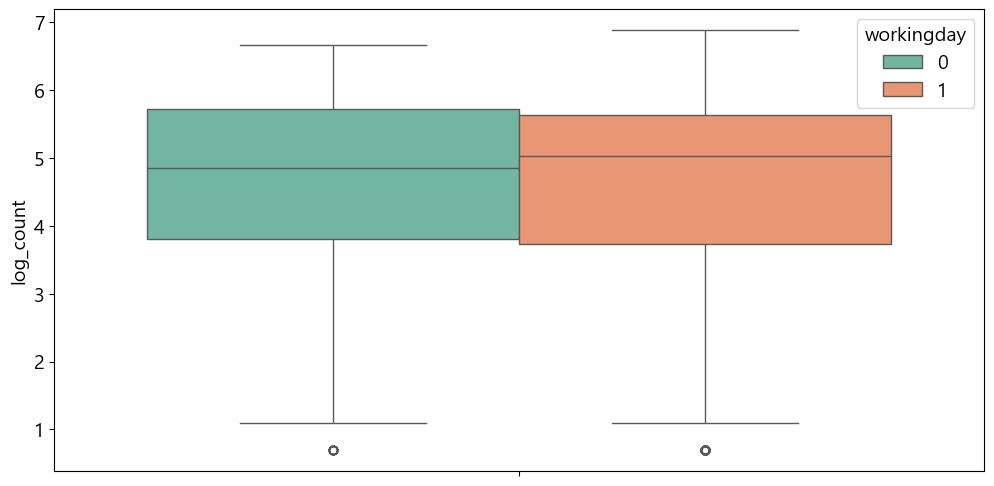

In [25]:
# workingday를 활용하여 boxplot 그리기
sns.boxplot(data=train_df, y='log_count', hue='workingday', palette='Set2')
plt.show()

- 크게 차이가 없어보임

,workingday,log_count
0,0,4.623139
1,1,4.576470


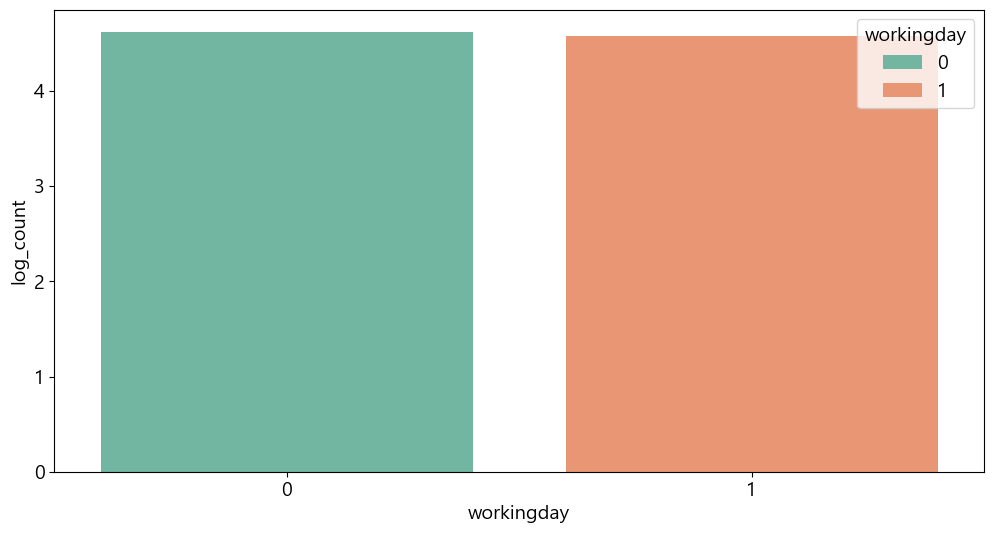

In [26]:
# Workingday 별 log_count의 평균 시각화
a1 = train_df.groupby('workingday', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='workingday', y='log_count', palette='Set2', hue='workingday')
plt.show()

- 업무일과 업무일이 아닌 날의 자전거 대여 횟수는 큰 차이를 보이지 않는다

### weather
- 날씨상태
- 1 = 맑음, 2 = 흐림, 3 = 비/눈, 4 = 악천후

In [27]:
# 도수분포 확인
train_df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

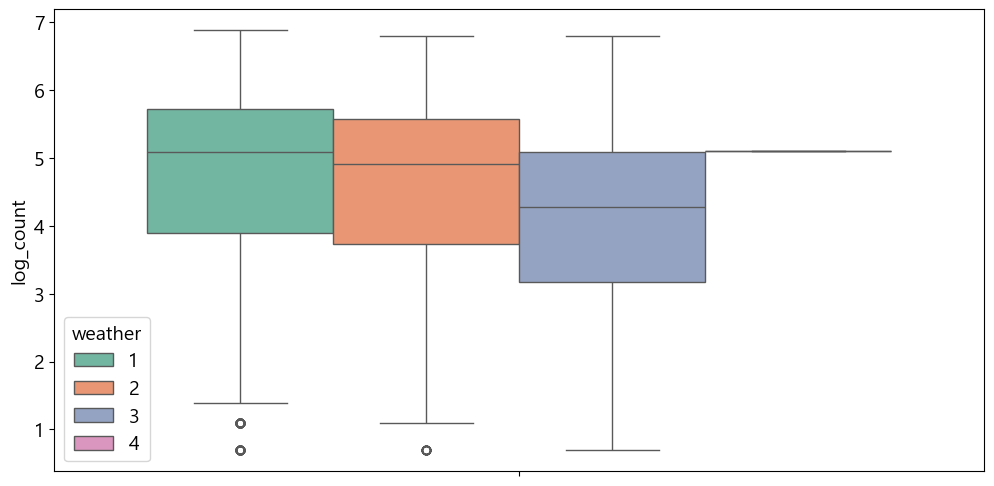

In [28]:
# weather를 활용하여 boxplot을 그려본다
sns.boxplot(data=train_df, y='log_count', hue='weather', palette='Set2')
plt.show()

,weather,log_count
3,4,5.105945
0,1,4.673980
1,2,4.545450
2,3,4.050533


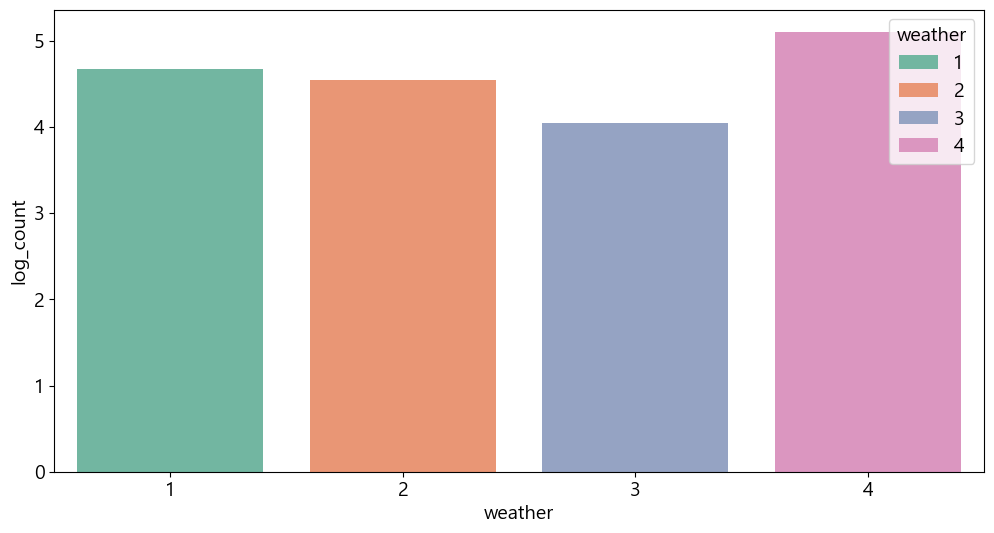

In [29]:
# weather 별 log_count의 평균 시각화
a1 = train_df.groupby('weather', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='weather', y='log_count', palette='Set2', hue='weather')
plt.show()

### 표본의 함정
- 통계적 유의성 부재
- 날씨 4번의 데이터는 전체 약 10,000건 중 단 1건에 불과하여 통계적으로 유의미한 평균값이라고 볼 수 없다.
- 제거하거나 편입을 시켜야 한다.

In [30]:
test_df['weather'].value_counts()

weather
1    4221
2    1710
3     560
4       2
Name: count, dtype: int64

In [31]:
# 예측해야할 데이터에 4가 있으므로 3에 편입한다.
idx1 = train_df.query('weather==4').index
idx2 = test_df.query('weather== 4').index

train_df.loc[idx1,'weather'] = 3
test_df.loc[idx2,'weather'] = 3

In [32]:
display(train_df['weather'].value_counts())
display(test_df['weather'].value_counts())

weather
1    7192
2    2834
3     860
Name: count, dtype: int64

weather
1    4221
2    1710
3     562
Name: count, dtype: int64

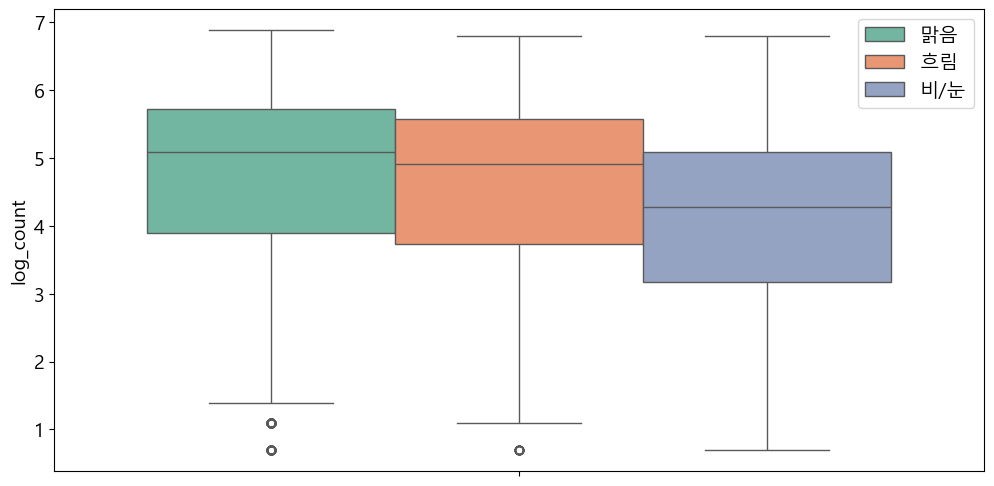

In [33]:
# weather를 활용하여 boxplot를 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='weather', palette='Set2')
plt.legend(labels=['맑음','흐림','비/눈'])
plt.show()

,weather,log_count
0,1,4.673980
1,2,4.545450
2,3,4.051761


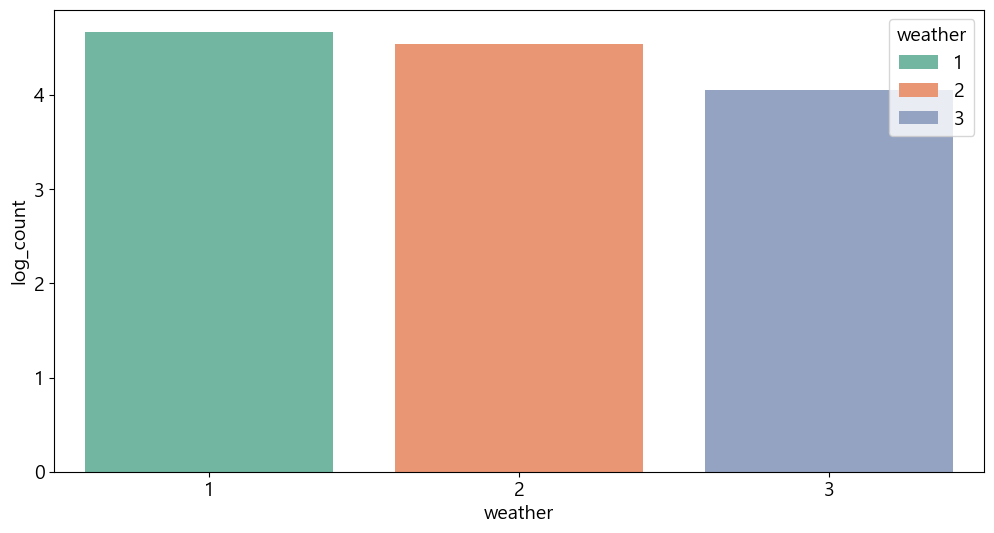

In [34]:
# weather 별 log_count의 평균 시각화
a1 = train_df.groupby('weather', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='weather', y='log_count', palette='Set2', hue='weather')
plt.show()

- 날씨가 좋을수록 자전거 대여 횟수는 증가한다.

### temp 
- 기온, 섭씨온도

In [35]:
# 위에는 전부 범주형 데이터들이여서 value_counts()로 확인했음
# 연속형 데이터는 히스토 그램 데이터를 가져온다.
a1 = np.histogram(train_df['temp'],bins=10)

index_list = []

for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}이하')
    else : 
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터 수'])

,데이터 수
0.820이상 4.838미만,69
4.838이상 8.856미만,648
8.856이상 12.874미만,1440
12.874이상 16.892미만,1891
16.892이상 20.910미만,1587
20.910이상 24.928미만,1753
24.928이상 28.946미만,1901
28.946이상 32.964미만,1194
32.964이상 36.982미만,355
36.982이상 41.000이하,48


<Axes: xlabel='temp', ylabel='Count'>

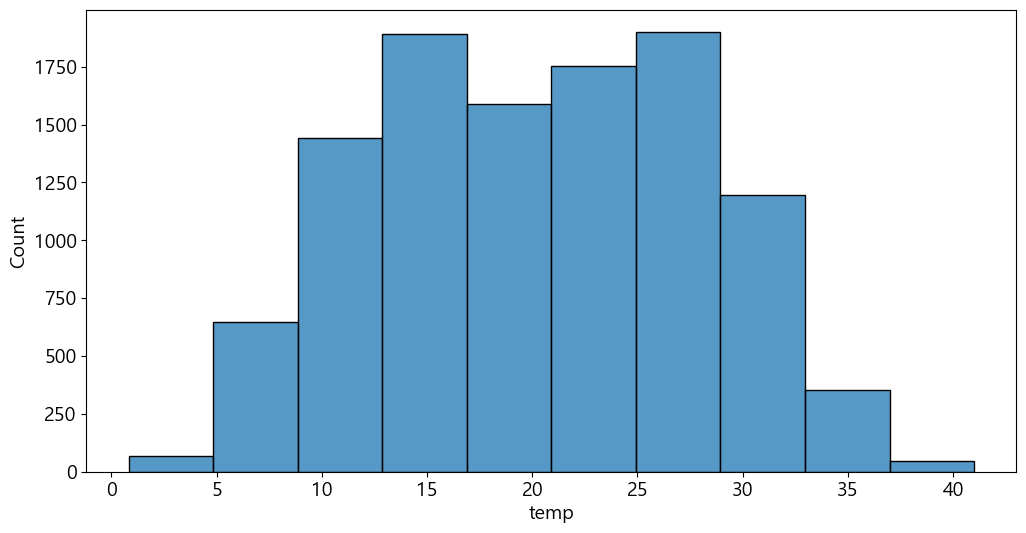

In [36]:
sns.histplot(data=train_df,x='temp',  bins=10)

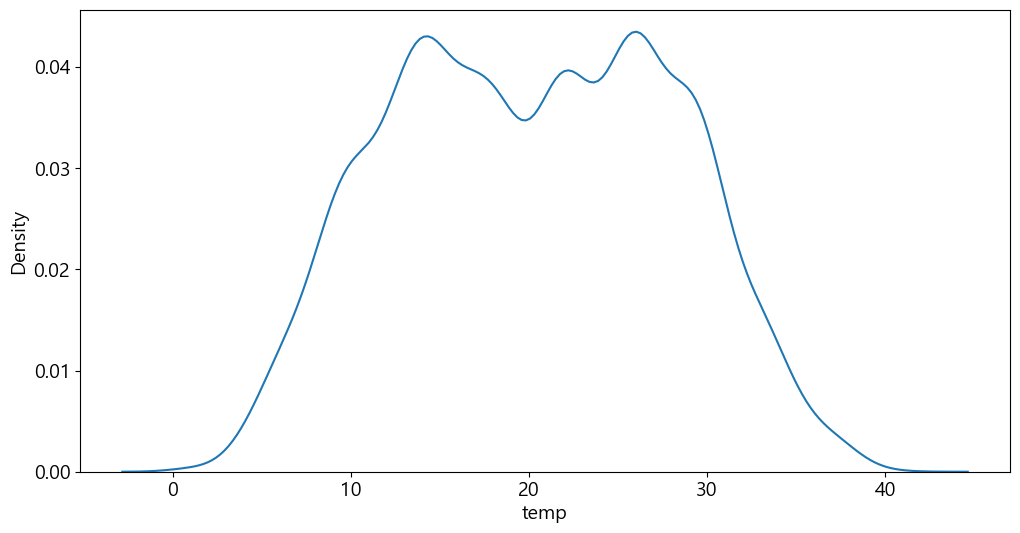

In [37]:
sns.kdeplot(data=train_df, x='temp')
plt.show()

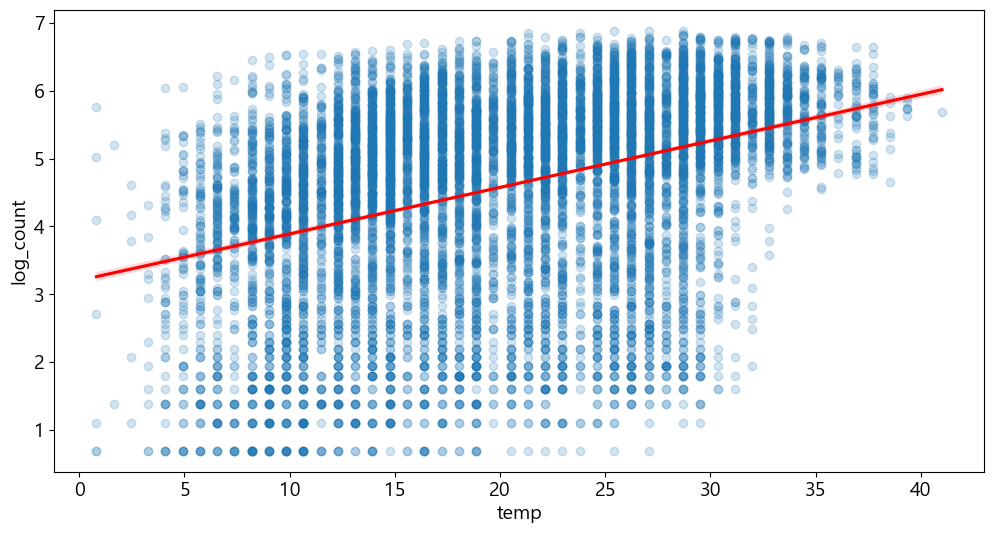

In [38]:
# 산점도와 회귀선 그리기
# 전체적인 데이터의 흐름과 상관관계를 한 눈에 파악할 때 사용한다.
# 회귀선을 추가하면 추세를 쉽게 알 수 있다.
sns.regplot(data=train_df, x='temp', y='log_count', 
            scatter_kws={'alpha':0.2}, # 겹쳐지는 부분 투명도 적용
            line_kws={'color':'red'} # 추세선 색상 변경
           )
plt.show()

- 온도가 올라감에 따라 추세선에따라 log_count()가 올라감을 확인 할 수 있다

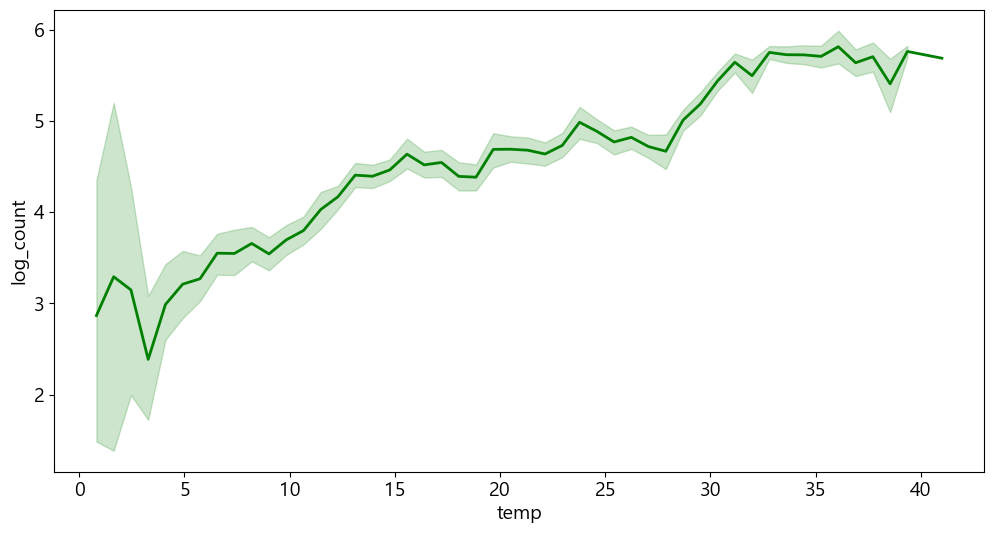

In [39]:
sns.lineplot(x='temp', y='log_count', data=train_df, color='green', linewidth=2)
plt.show()

- 온도가 높을수록 자전거 대여 횟수는 증가한다.

### atemp
- 체감 온도, 섭씨 온도

In [40]:
a1 = np.histogram(train_df['atemp'], bins=10)
index_list = []
for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f} 이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f} 미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터 수'])

,데이터 수
0.760이상 5.229 미만,44
5.229이상 9.699 미만,406
9.699이상 14.168 미만,1243
14.168이상 18.638 미만,1679
18.638이상 23.108 미만,1790
23.108이상 27.577 미만,1962
27.577이상 32.047 미만,1832
32.047이상 36.516 미만,1425
36.516이상 40.985 미만,440
40.985이상 45.455 이하,65


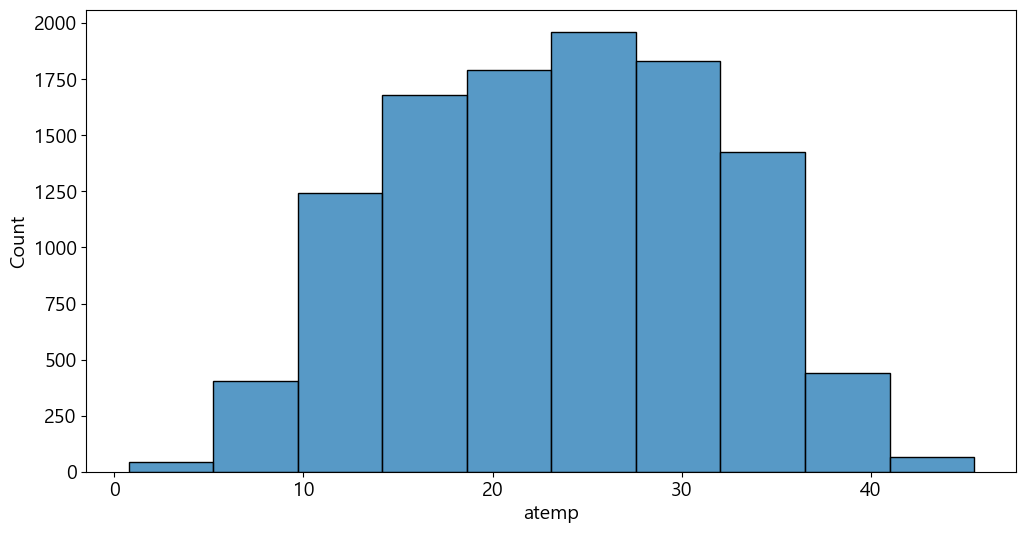

In [41]:
sns.histplot(data=train_df, x='atemp', bins=10)
plt.show()

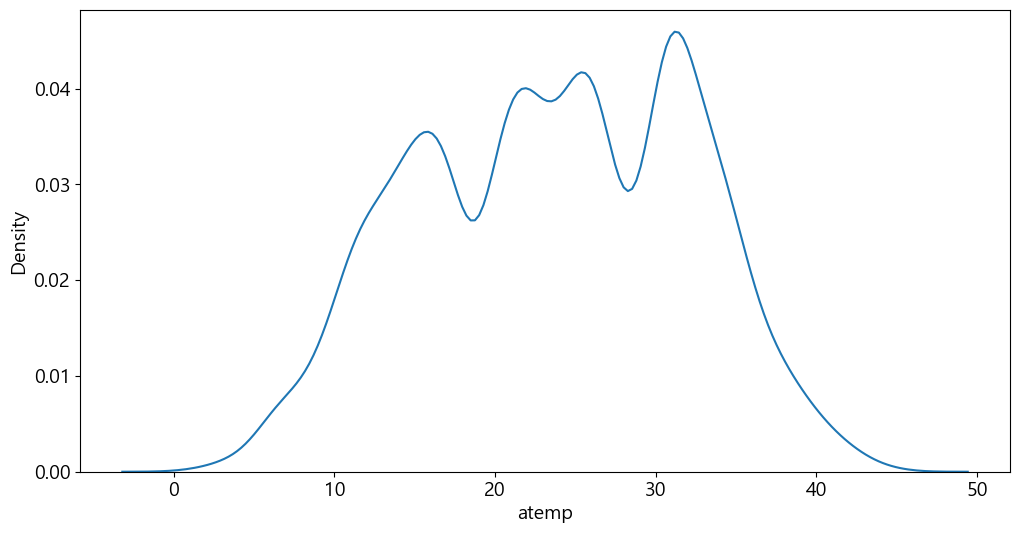

In [42]:
sns.kdeplot(data=train_df, x='atemp')
plt.show()

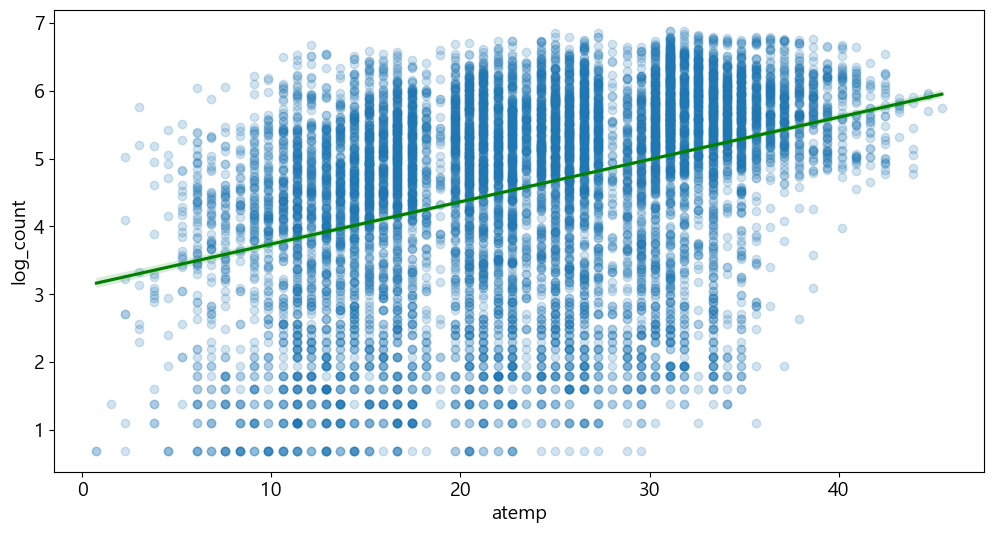

In [43]:
sns.regplot(x='atemp', y='log_count', data=train_df,
           scatter_kws={'alpha' : 0.2},
           line_kws={'color' : 'green'})
plt.show()

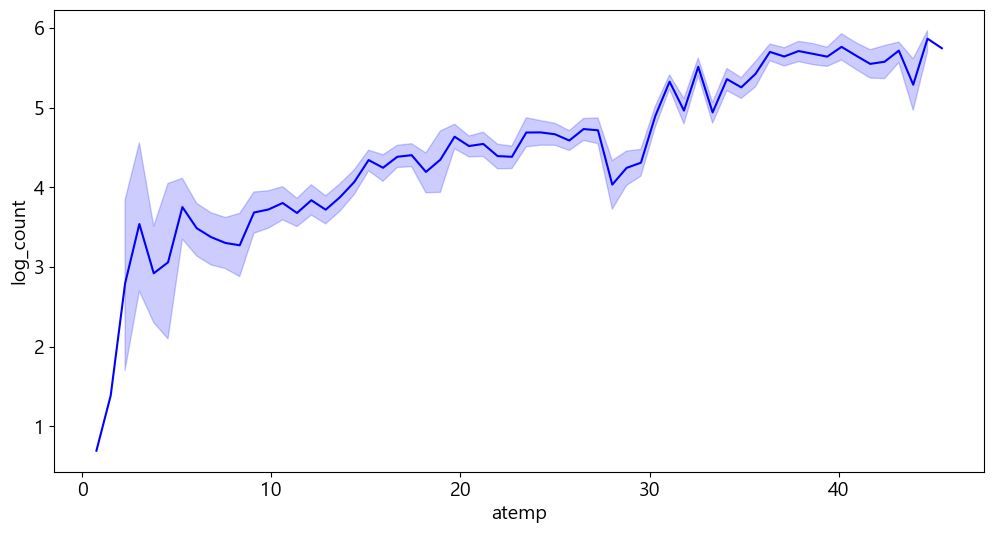

In [44]:
sns.lineplot(x='atemp', y='log_count', data= train_df, color='blue')
plt.show()

- 체감온도가 상승하면 자전거 대여 횟수도 증가한다

### humidity 
- 습도

In [45]:
a1 = np.histogram(train_df['humidity'], bins=10)
index_list = []

for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) -2 :
        index_list.append(f'{a1[1][v1]:.3f} 이상 {a1[1][v1 + 1 ]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f} 미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터 수'])

,데이터 수
0.000이상 10.000 미만,23
10.000이상 20.000 미만,45
20.000이상 30.000 미만,364
30.000이상 40.000 미만,1039
40.000이상 50.000 미만,1727
50.000이상 60.000 미만,1842
60.000이상 70.000 미만,1748
70.000이상 80.000 미만,1736
80.000이상 90.000 미만,1676
90.000 이상 100.000이하,686


<Axes: xlabel='humidity', ylabel='Count'>

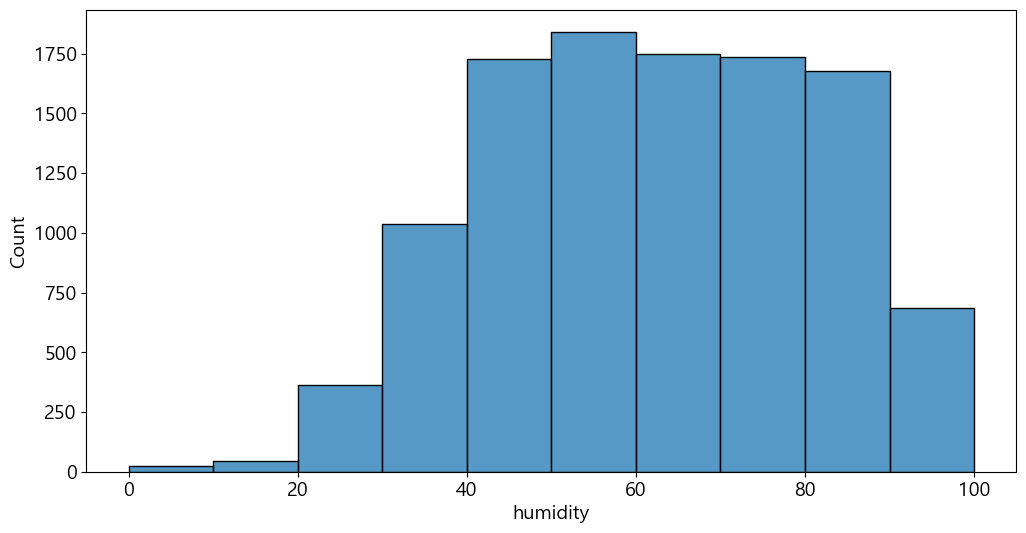

In [46]:
sns.histplot(data=train_df, x='humidity', bins=10)

<Axes: xlabel='humidity', ylabel='Density'>

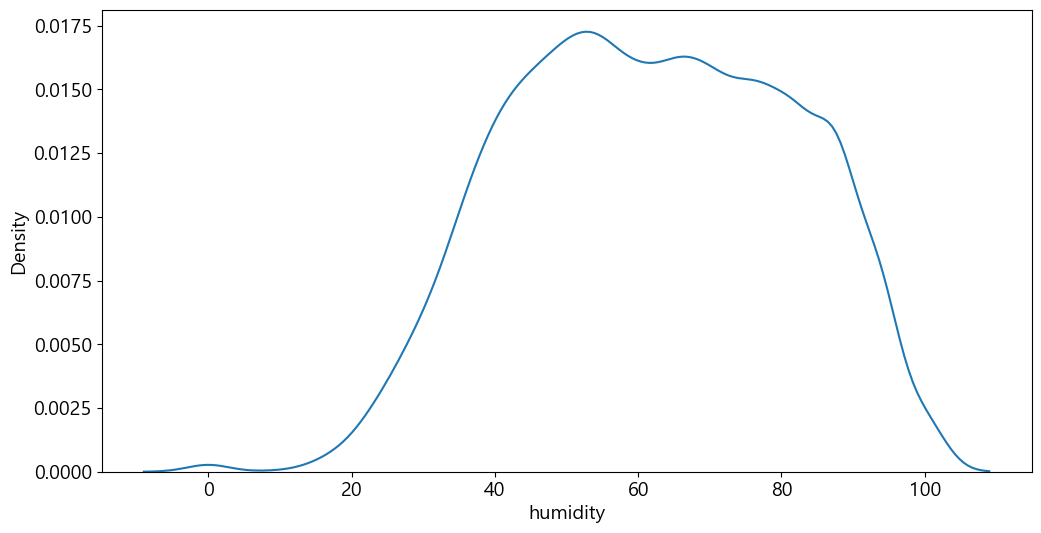

In [47]:
sns.kdeplot(data=train_df, x='humidity')

In [48]:
# 왜도 계산 (0에 가까울 수록 정규분포, 1이상이면 왜도가 심함)
skew_hum = train_df['humidity'].skew()
print(f'습도의 왜도 : {skew_hum:.2f}')

습도의 왜도 : -0.09


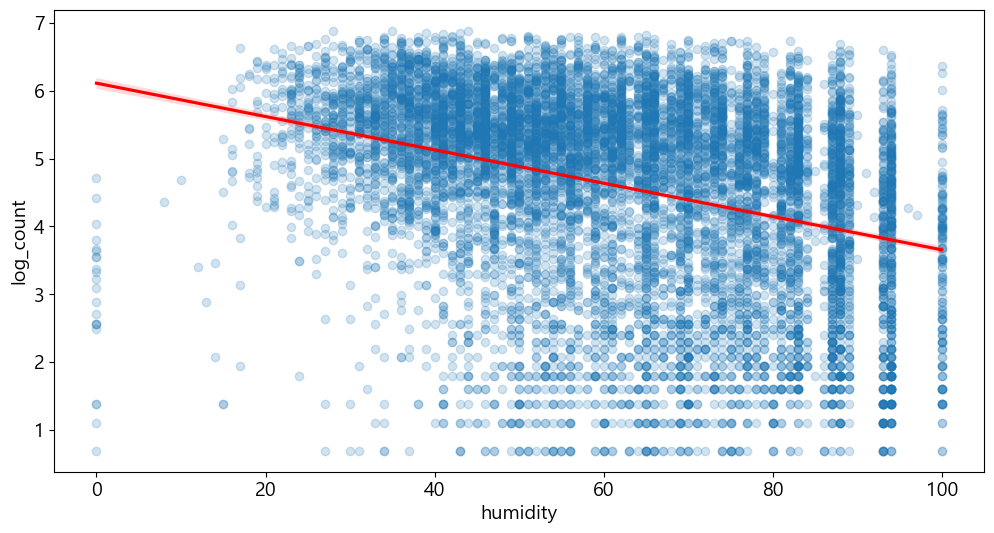

In [49]:
sns.regplot(data = train_df, x='humidity', y='log_count',
            scatter_kws={'alpha' : 0.2},
            line_kws={'color' : 'red'})
plt.show()

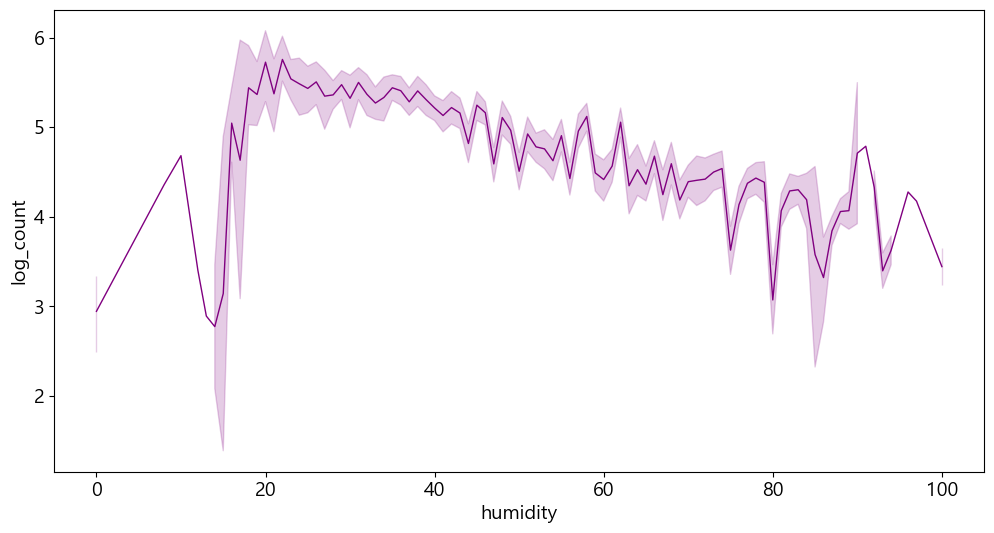

In [50]:
sns.lineplot(data=train_df, x='humidity', y='log_count', color='purple', linewidth=1)
plt.show()

- 습도가 올라갈 수록 자전거 대여 수는 감소한다.

### windspeed 
- 풍속

In [51]:
a1 = np.histogram(train_df['windspeed'], bins=10)
index_list = []

for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) -2 :
        index_list.append(f'{a1[1][v1]:.3f} 이상 {a1[1][v1 + 1 ]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f} 미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터 수'])

,데이터 수
0.000이상 5.700 미만,1313
5.700이상 11.399 미만,4083
11.399이상 17.099 미만,2827
17.099이상 22.799 미만,1540
22.799이상 28.498 미만,696
28.498이상 34.198 미만,280
34.198이상 39.898 미만,107
39.898이상 45.598 미만,31
45.598이상 51.297 미만,6
51.297 이상 56.997이하,3


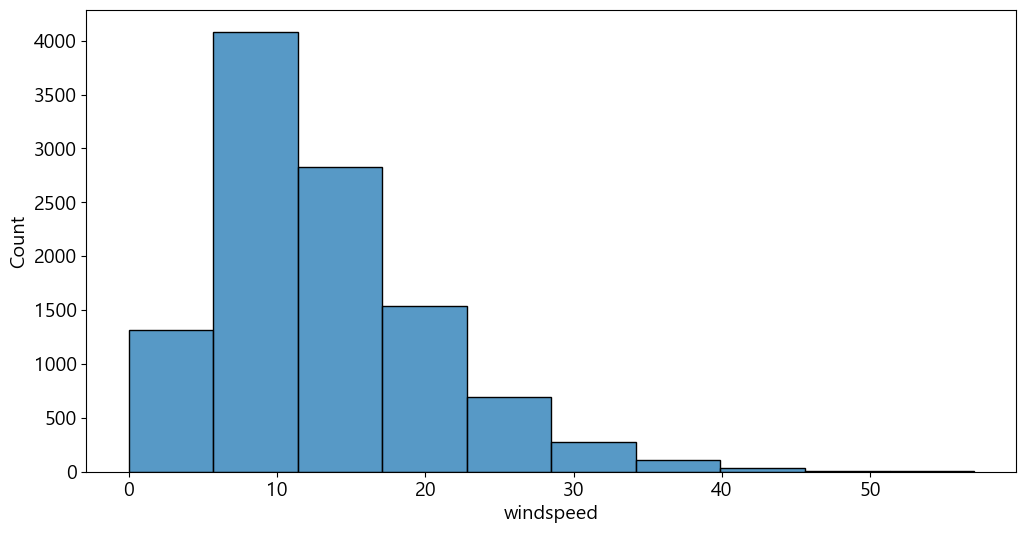

In [52]:
sns.histplot(data=train_df, x='windspeed', bins=10)
plt.show()

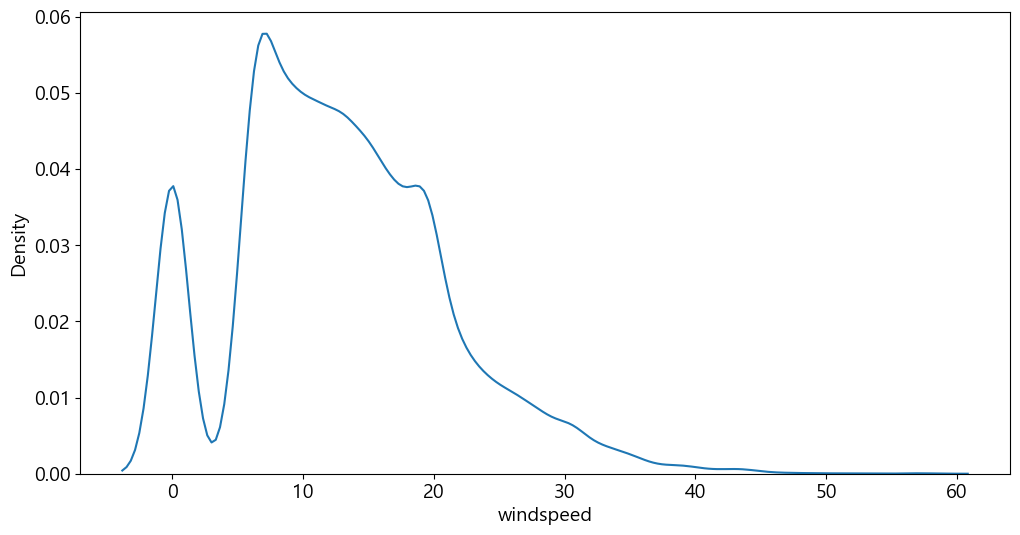

In [53]:
sns.kdeplot(data=train_df, x='windspeed')
plt.show()

In [54]:
# 왜도 계산
skew_wind = train_df['windspeed'].skew()
print(f'바람세기 : {skew_wind:.2f}')

바람세기 : 0.59


In [55]:
# 로그값을 취한 컬럼을 추가한다.
train_df['log_windspeed'] = np.log1p(train_df['windspeed'])
test_df['log_windspeed'] = np.log1p(test_df['windspeed'])

In [56]:
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count,year,month,day,hour,log_windspeed
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213,2011,1,1,0,0.000000
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572,2011,1,1,1,0.000000
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508,2011,1,1,2,0.000000
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057,2011,1,1,3,0.000000
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147,2011,1,1,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083,2012,12,19,19,3.295937
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938,2012,12,19,20,2.772670
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899,2012,12,19,21,2.772670
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534,2012,12,19,22,1.946367


In [57]:
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,log_windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3.295937
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,0.000000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,0.000000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,2.485023
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,2.485023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19,2.485023
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20,2.485023
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21,2.485023
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22,2.302395


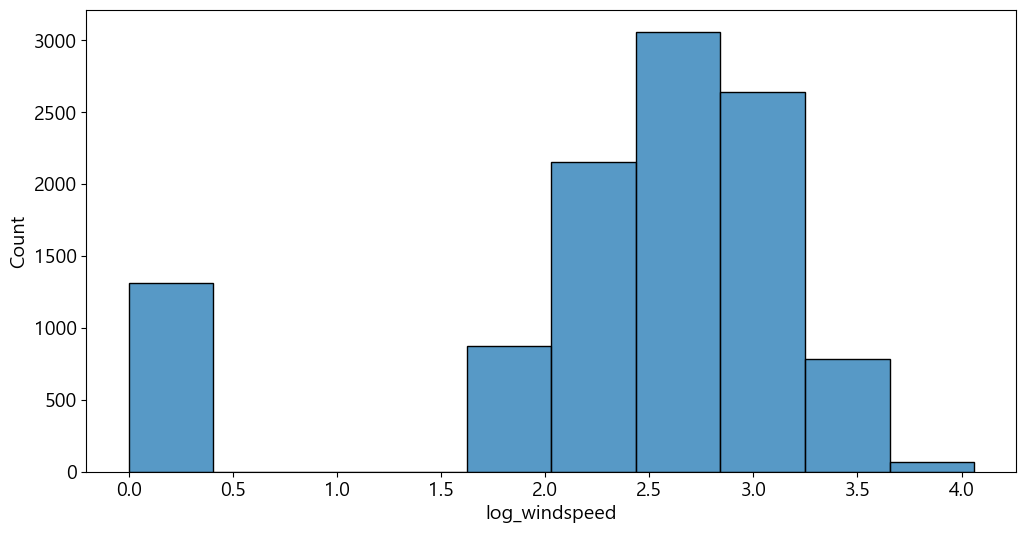

In [58]:
sns.histplot(data=train_df, x='log_windspeed', bins=10)
plt.show()

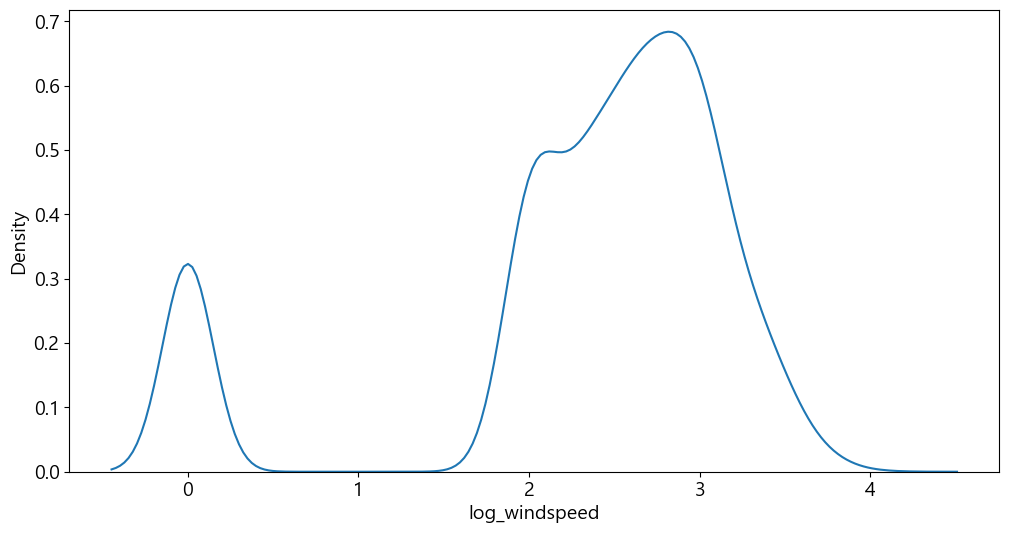

In [59]:
sns.kdeplot(data=train_df, x='log_windspeed')
plt.show()

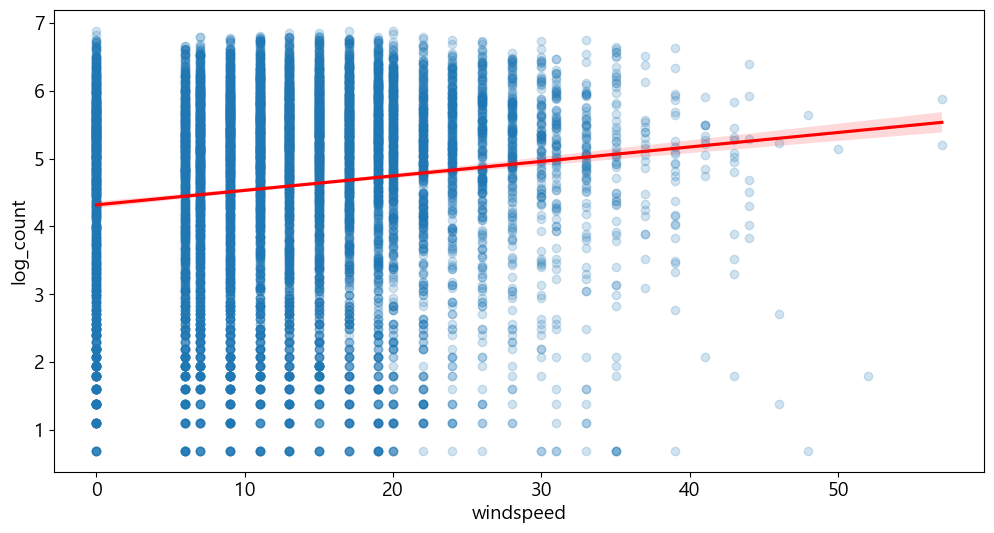

In [60]:
# windspeed의 산점도와 회귀선
sns.regplot(data=train_df, x='windspeed', y='log_count',
            scatter_kws={'alpha' : 0.2},
            line_kws={'color' : 'red'})
plt.show()

- 바람세기가 커질수록 자전거 대여수가 올라가는 추세를 보여줌
- 추세선의 면적은 오차이다

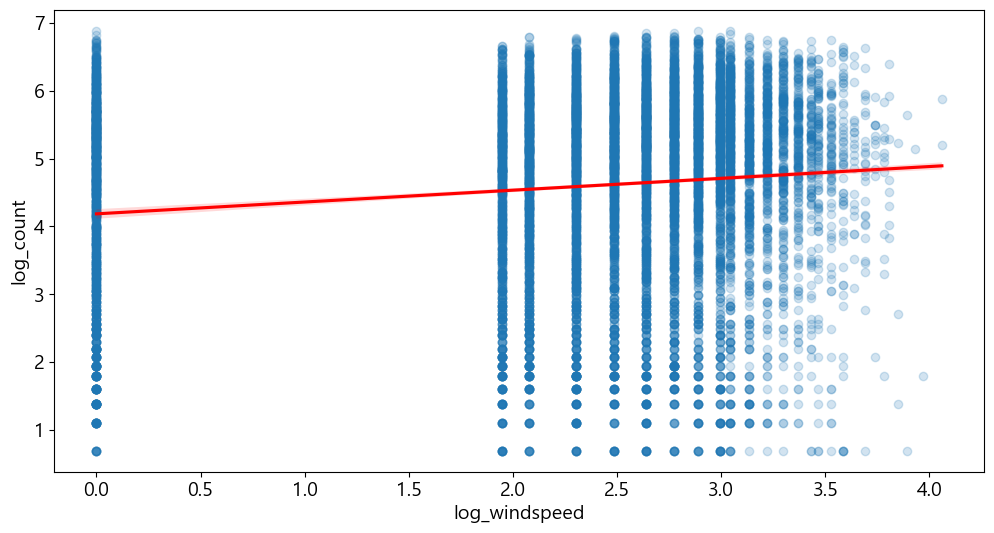

In [61]:
# log_windspeed의 산점도와 회귀선
sns.regplot(data=train_df,x='log_windspeed', y='log_count',
            scatter_kws={'alpha' : 0.2},
            line_kws={'color' : 'red'})
plt.show()

- 바람세기가 커질수록 자전거 대여수가 올라가는 추세를 보여줌
- 추세선의 오차 범위가 이전 데이터보다 별로 없음을 확인할 수 있다.

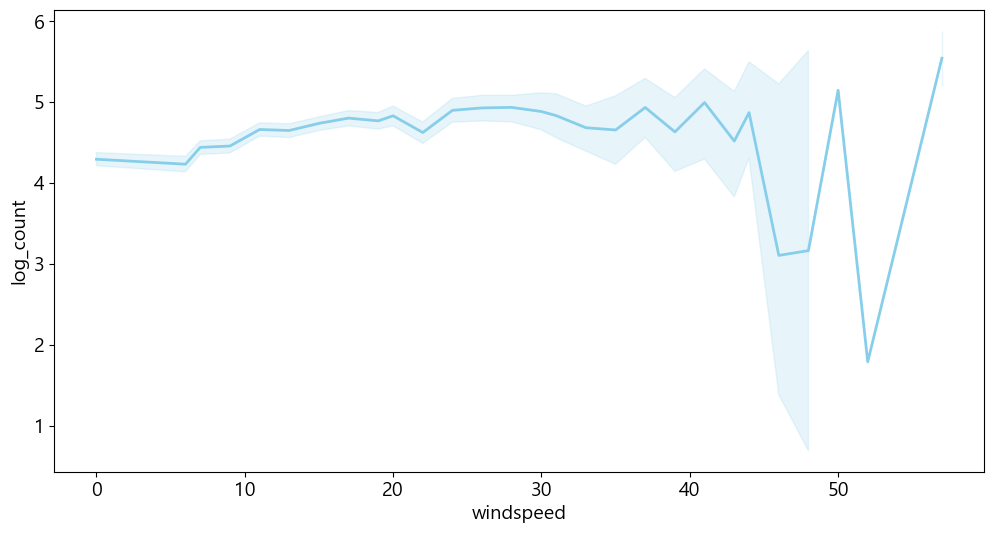

In [62]:
# windspeed 의 평균 선
sns.lineplot(data=train_df, x='windspeed', y='log_count', color='skyblue', linewidth=2)
plt.show()

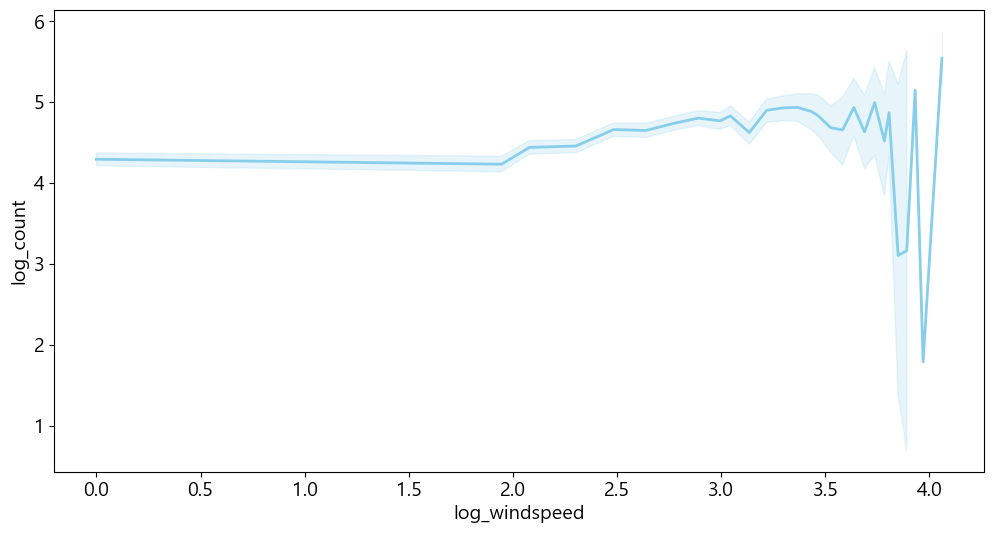

In [63]:
# log_windspeed의 평균선
sns.lineplot(data=train_df, x='log_windspeed', y='log_count', color = 'skyblue', linewidth=2)
plt.show()

- windspeed가 증가할 수록 자전거 대여 수도 증가한다

### year

In [64]:
train_df['year'].value_counts()

year
2012    5464
2011    5422
Name: count, dtype: int64

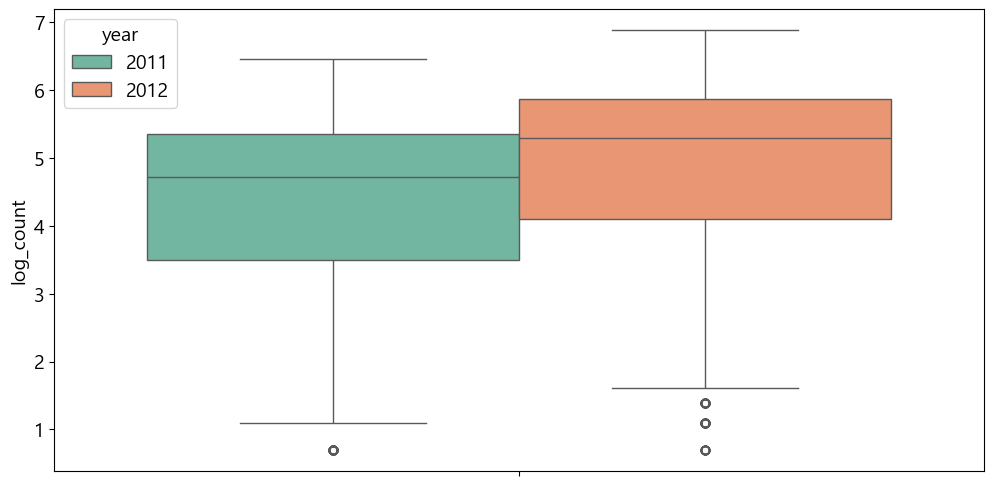

In [65]:
# year를 활용하여 boxplot 그리기
sns.boxplot(data=train_df, y='log_count', hue='year', palette='Set2')
plt.show()

In [66]:
# year 별 로그카운트 평균 시각화
a1 = train_df.groupby('year', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

,year,log_count
1,2012,4.843376
0,2011,4.337399


<Axes: xlabel='year', ylabel='log_count'>

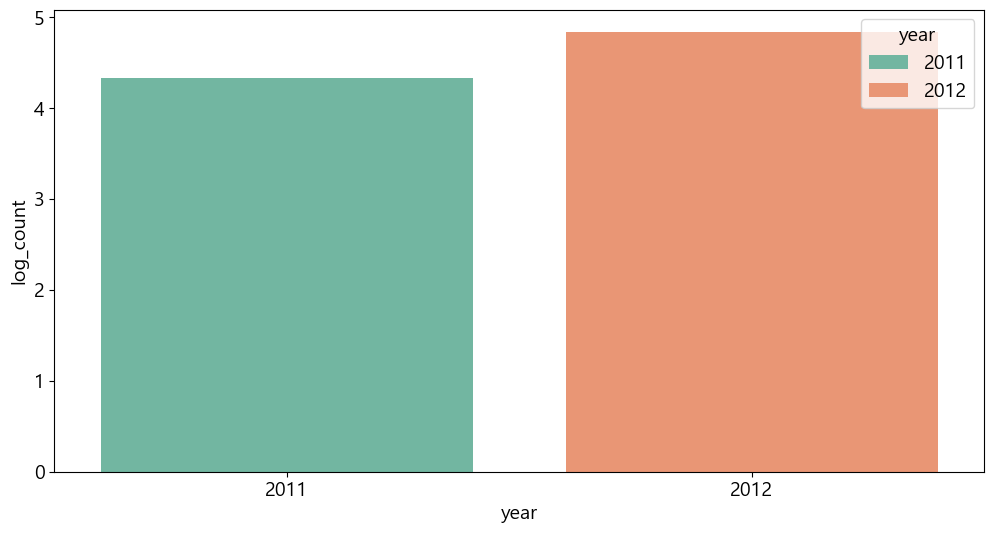

In [67]:
sns.barplot(data=a1, x='year', y='log_count', palette='Set2', hue='year')

- 2011년에 비해 2012년에 자전거 대여 횟수가 증가했다

### month

In [68]:
train_df['month'].value_counts()

month
5     912
6     912
7     912
8     912
12    912
10    911
11    911
4     909
9     909
2     901
3     901
1     884
Name: count, dtype: int64

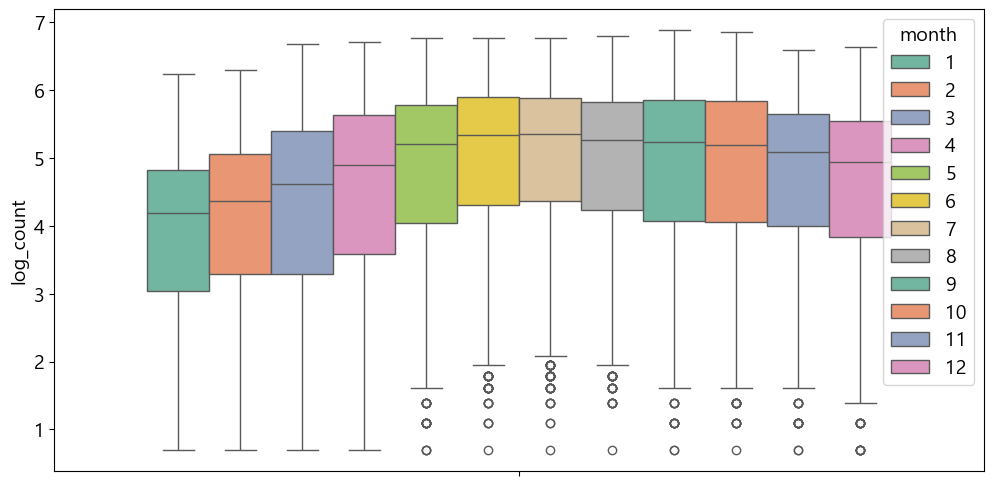

In [69]:
# month를 활용하여 boxplot를 그리기
sns.boxplot(data=train_df, y='log_count', hue='month', palette='Set2')
plt.show()

,month,log_count
6,7,4.928314
5,6,4.917041
7,8,4.887959
8,9,4.839759
9,10,4.812821
4,5,4.786222
10,11,4.679616
11,12,4.561363
3,4,4.504310
2,3,4.250942


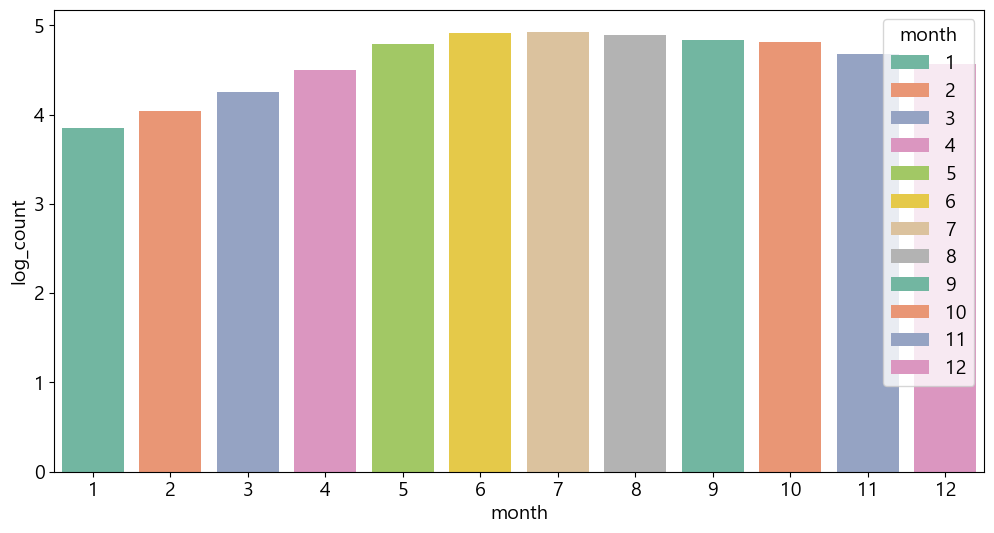

In [70]:
# month 별 평균 시각화
a1 = train_df.groupby('month', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)

display(a2)

sns.barplot(data=a1, x='month', y='log_count', palette='Set2', hue='month')
plt.show()

- 1월이 대여 수가 가장 낮고 월이 증가할수록 자전거 대여 수가 증가하다가 11월 부터 감소 추세를 보임
- 겨울이 될 수록 자전거 대여 수가 내려가는 경향

### day

In [71]:
train_df['day'].value_counts()

day
1     575
5     575
9     575
17    575
4     574
7     574
8     574
13    574
14    574
15    574
16    574
19    574
2     573
3     573
12    573
6     572
10    572
11    568
18    563
Name: count, dtype: int64

<Axes: xlabel='day', ylabel='log_count'>

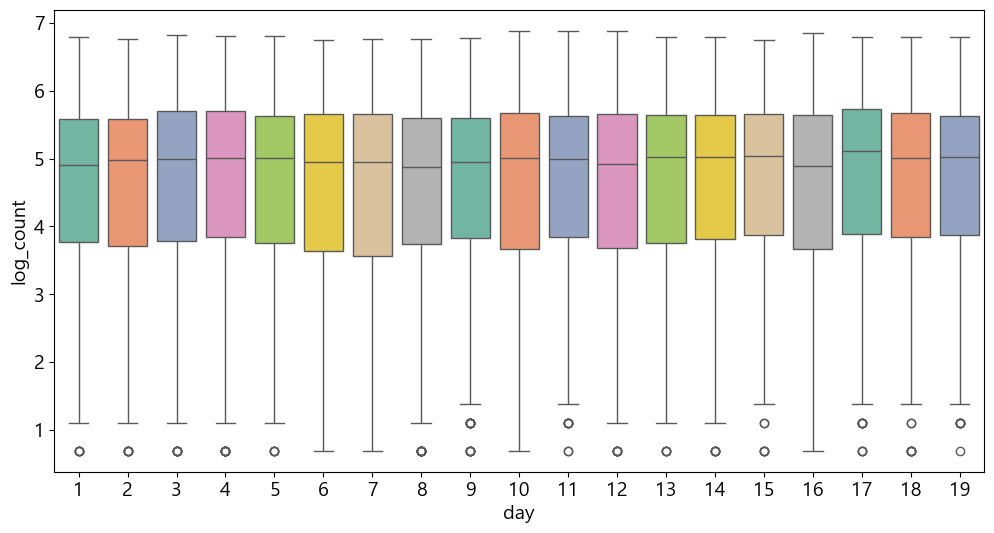

In [72]:
# day를 활용하여 boxplot를 그리기
sns.boxplot(data=train_df, x='day', y='log_count', palette='Set2')

,day,log_count
16,17,4.673950
14,15,4.673179
17,18,4.648012
10,11,4.635093
13,14,4.616197
18,19,4.615717
3,4,4.607368
12,13,4.598360
2,3,4.597414
9,10,4.588190


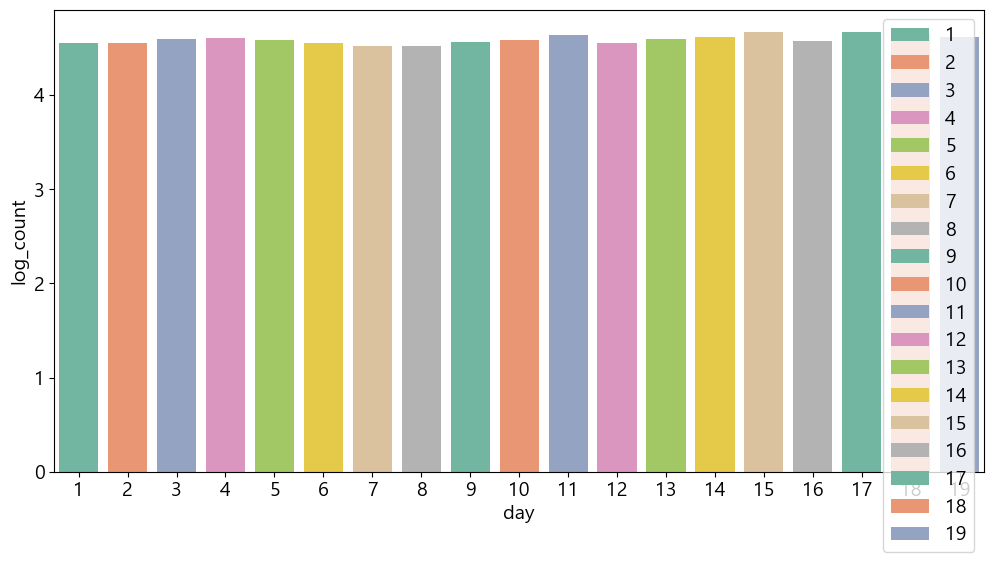

In [73]:
a1 = train_df.groupby('day', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='day', y='log_count', palette='Set2', hue='day')
plt.legend()
plt.show()

- day와 자전거 대여횟수는 관계가 없음을 확인할 수 있다.

### hour

In [74]:
train_df['hour'].value_counts()

hour
12    456
13    456
14    456
15    456
16    456
17    456
18    456
19    456
20    456
21    456
22    456
23    456
0     455
6     455
7     455
8     455
9     455
10    455
11    455
1     454
5     452
2     448
4     442
3     433
Name: count, dtype: int64

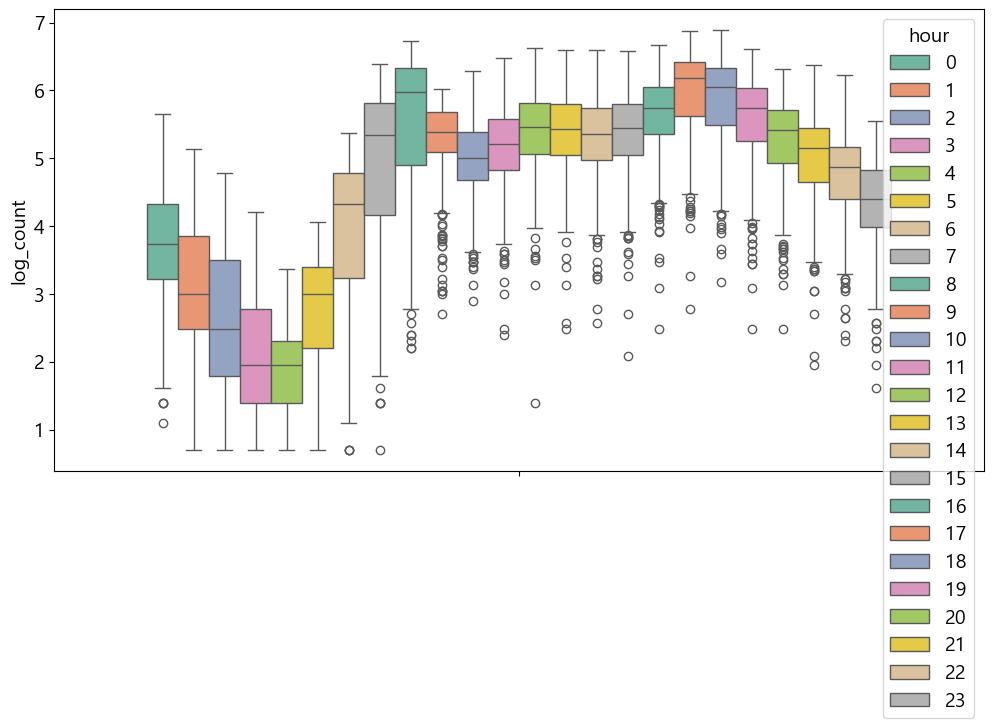

In [75]:
# hour의 boxplot으로 그리기
sns.boxplot(data=train_df, y='log_count', hue='hour', palette='Set2')
plt.show()

,hour,log_count
17,17,6.000667
18,18,5.898224
16,16,5.617140
19,19,5.591497
8,8,5.575184
13,13,5.377655
12,12,5.374850
15,15,5.359728
14,14,5.304810
9,9,5.284876


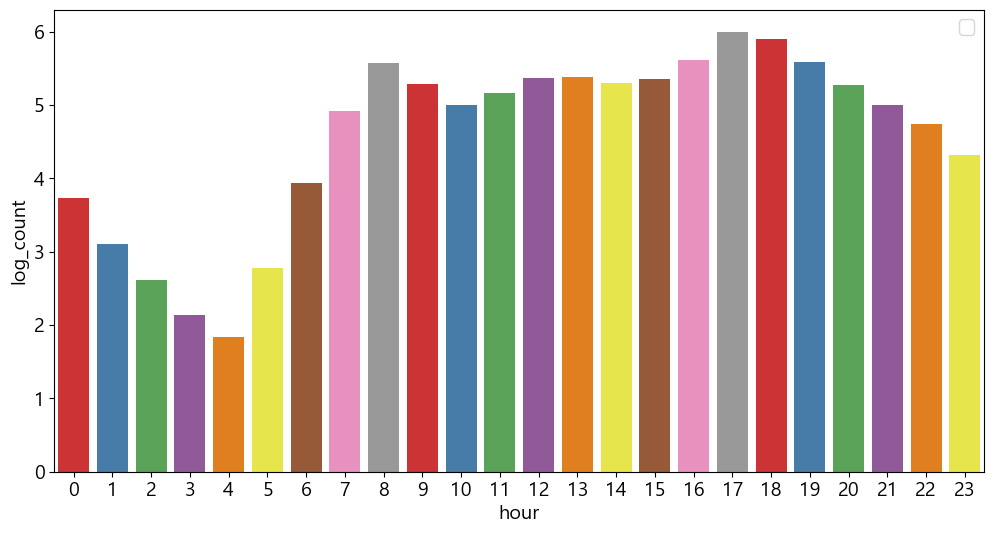

In [76]:
# hour의 평균 시각화
a1 = train_df.groupby('hour',as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='hour', y='log_count', palette='Set1')
plt.legend()
plt.show()

- 오전 4시 이후 부터 자전거 대여 수가 증가하다가 9시쯤에 정점을 찍고 살짝 감소한 상태로 유지된다.
- 오후 3시 부터 자전거 대여수가 증가하다가 6시쯤에 정점을 찍고 눈에 띄게 감소한다.

### 불필요한 컬럼 제거

In [77]:
train_df.drop(['datetime','count'],axis=1,inplace=True)
test_df.drop(['datetime'],axis=1,inplace=True)
train_df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,log_count,year,month,day,hour,log_windspeed
0,1,0,0,1,9.84,14.395,81,0.0000,2.833213,2011,1,1,0,0.000000
1,1,0,0,1,9.02,13.635,80,0.0000,3.713572,2011,1,1,1,0.000000
2,1,0,0,1,9.02,13.635,80,0.0000,3.496508,2011,1,1,2,0.000000
3,1,0,0,1,9.84,14.395,75,0.0000,2.639057,2011,1,1,3,0.000000
4,1,0,0,1,9.84,14.395,75,0.0000,0.693147,2011,1,1,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,5.820083,2012,12,19,19,3.295937
10882,4,0,1,1,14.76,17.425,57,15.0013,5.488938,2012,12,19,20,2.772670
10883,4,0,1,1,13.94,15.910,61,15.0013,5.129899,2012,12,19,21,2.772670
10884,4,0,1,1,13.94,17.425,61,6.0032,4.867534,2012,12,19,22,1.946367


In [78]:
test_df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,log_windspeed
0,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3.295937
1,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,0.000000
2,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,0.000000
3,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,2.485023
4,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,2.485023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19,2.485023
6489,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20,2.485023
6490,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21,2.485023
6491,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22,2.302395


In [ ]:
train_df.to_csv('data/bike_sharing_train2.csv'